=== Dataset Shape ===
(200, 5)
=== First 5 Rows ===
   square_footage  bedrooms  age_years  location_score          price
0            3674         4          1               4  949707.821661
1            1360         4         31               5  524797.535086
2            1794         3         22               4  561502.053428
3            1630         2         21               5  548433.082536
4            1595         4         24               7  623847.254692
=== Statistical Summary ===
       square_footage    bedrooms   age_years  location_score         price
count      200.000000  200.000000  200.000000      200.000000  2.000000e+02
mean      2333.775000    2.780000   25.180000        5.330000  6.968919e+05
std        992.421831    1.393308   14.055797        2.917819  2.149161e+05
min        521.000000    1.000000    0.000000        1.000000  2.169028e+05
25%       1519.000000    1.000000   13.000000        3.000000  5.467120e+05
50%       2372.000000    3.000000   25.00000

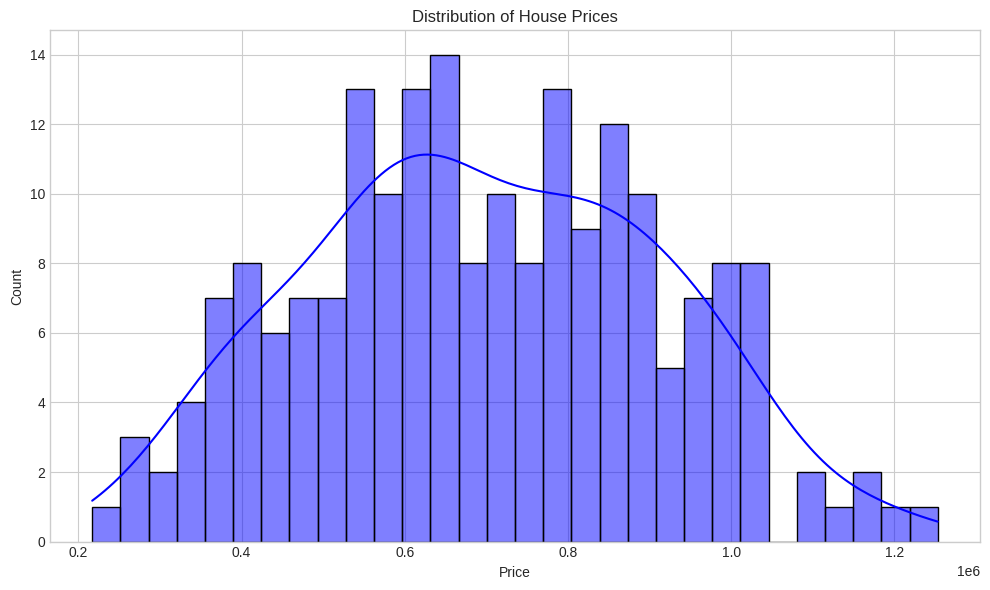

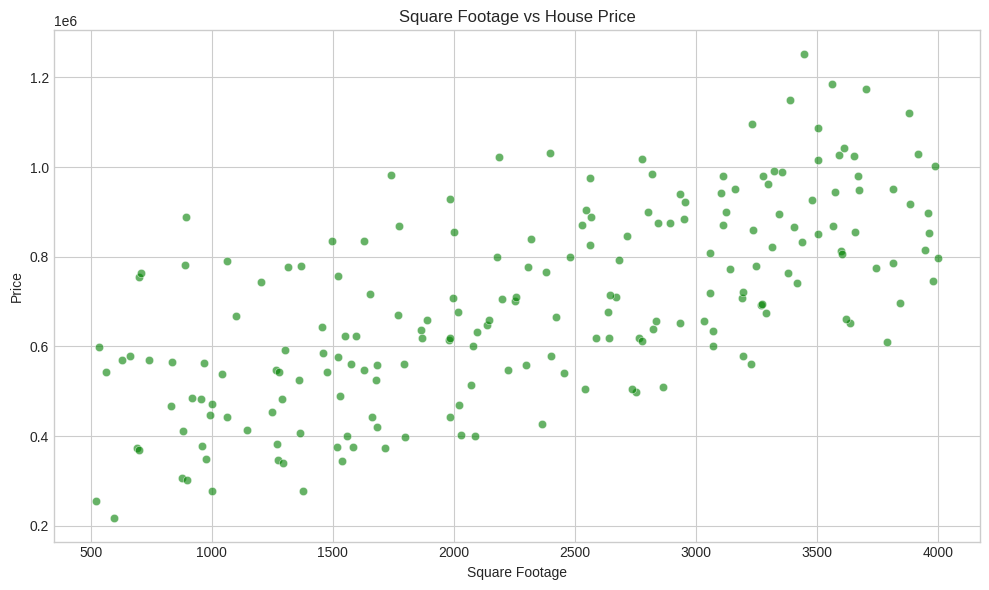

/tmp/ipykernel_5266/3825553816.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=house_data, x='bedrooms', y='price', palette='Set2')


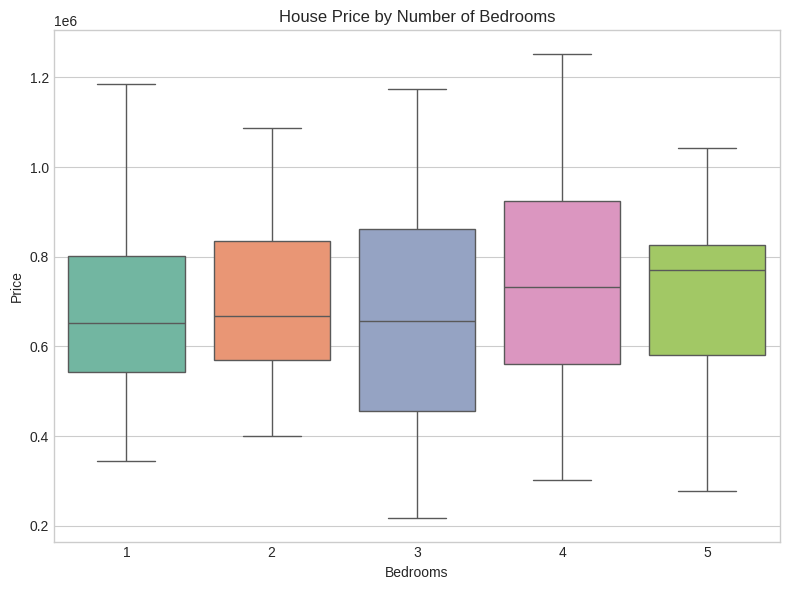

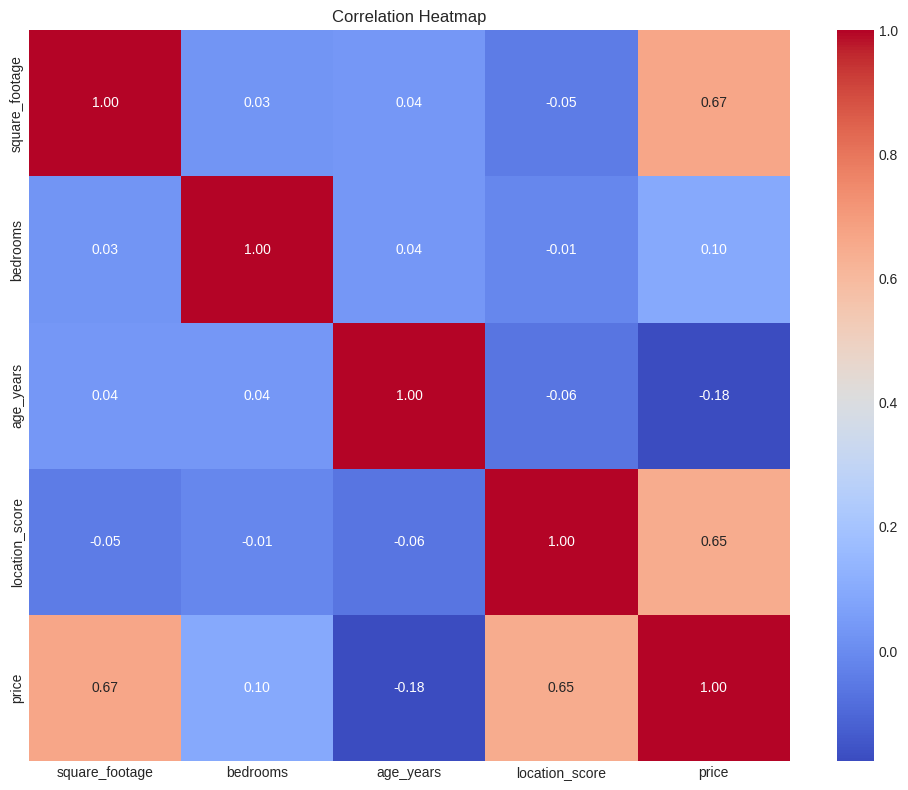

 === Data Split ===
Training samples: 160
Testing samples: 40
 === Model Coefficients ===
Square Footage: 149.03081194069986
Bedrooms: 12069.676150494051
Age Years: -2551.228320414024
Location Score: 48798.42123651067
Intercept: 118396.61147831776
 === Model Performance ===
R2 Score: 0.9526954781973535
MSE: 2998805906.4849305
RMSE: 54761.354133046516
MAE: 45913.79221234248


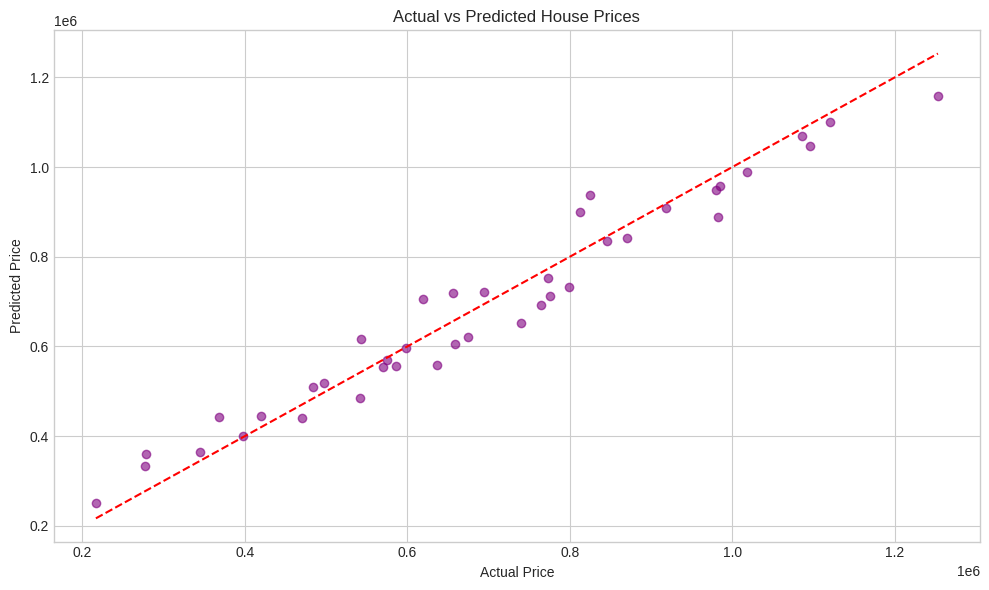

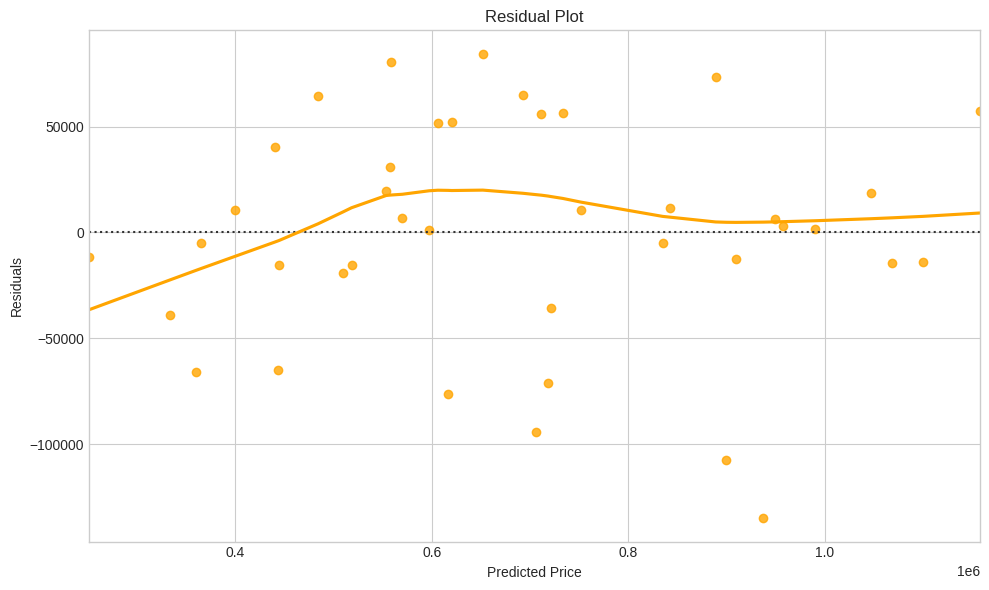

=== Sample Prediction ===
Predicted Price for sample house: 817542.35
 All plots saved successfully.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

n_samples = 200

square_footage = np.random.randint(500, 4000, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
age_years = np.random.randint(0, 50, n_samples)
location_score = np.random.randint(1, 11, n_samples)

price = (
    100000 +
        square_footage * 150 +
            bedrooms * 10000 -
                age_years * 2000 +
                    location_score * 50000 +
                        np.random.normal(0, 50000, n_samples)
                        )

house_data = pd.DataFrame({
                            'square_footage': square_footage,
                                'bedrooms': bedrooms,
                                    'age_years': age_years,
                                        'location_score': location_score,
                                            'price': price
                                            })

print("=== Dataset Shape ===")
print(house_data.shape)

print("=== First 5 Rows ===" )

print(house_data.head())

print("=== Statistical Summary ===")

print(house_data.describe())

print(" === Missing Values ===")

print(house_data.isnull().sum())

print(" === Correlation with Price ===")

print(house_data.corr(numeric_only=True)['price'])

plt.figure(figsize=(10, 6))
sns.histplot(house_data['price'], bins=30, kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('house_price_distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=house_data, x='square_footage', y='price', alpha=0.6, color='green')
plt.title('Square Footage vs House Price')
plt.xlabel('Square Footage')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('square_footage_vs_price.png', dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=house_data, x='bedrooms', y='price', palette='Set2')
plt.title('House Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.tight_layout()
plt.savefig('bedrooms_vs_price.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(house_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('house_data_correlation.png', dpi=300)
plt.show()

X = house_data[['square_footage', 'bedrooms', 'age_years', 'location_score']]
y = house_data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(" === Data Split ===")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

model = LinearRegression()
model.fit(X_train, y_train)

print(" === Model Coefficients ===")

print("Square Footage:", model.coef_[0])
print("Bedrooms:", model.coef_[1])
print("Age Years:", model.coef_[2])
print("Location Score:", model.coef_[3])
print("Intercept:", model.intercept_)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(" === Model Performance ===")

print("R2 Score:", r2)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, color='orange')
plt.title('Residual Plot')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=300)
plt.show()

sample_house = pd.DataFrame({
        'square_footage': [2000],
             'bedrooms': [3],
                 'age_years': [10],
                      'location_score': [8]
})

predicted_price = model.predict(sample_house)

print("=== Sample Prediction ===")

print("Predicted Price for sample house:", round(predicted_price[0], 2))
print(" All plots saved successfully.")
